## Overview
- RNN
    - a more advanced NN but it is harder to optimize the RNN thorugh gradient descent
 
- To Improve from MLP part 2
    - Initialization
    - Batch Norm

## Refs
- [makremore github](https://github.com/karpathy/makemore)
- [lecture jupyter lab](https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/makemore/makemore_part3_bn.ipynb)
- [lecture video](https://www.youtube.com/watch?v=P6sfmUTpUmc&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=4)
- [kaiming initialization](https://arxiv.org/abs/1502.01852)
- [batch norm](https://arxiv.org/abs/1502.03167)
- [batch norm problem](https://arxiv.org/abs/2105.07576)

## Makemore 

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [4]:
# read in all the words
words = open('./assets/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


In [29]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 27.8817
  10000/ 200000: 2.4496
  20000/ 200000: 2.8812
  30000/ 200000: 2.9212
  40000/ 200000: 2.1033
  50000/ 200000: 2.8599
  60000/ 200000: 2.3497
  70000/ 200000: 2.0208
  80000/ 200000: 2.3932
  90000/ 200000: 2.1366
 100000/ 200000: 1.9450
 110000/ 200000: 2.3361
 120000/ 200000: 1.8785
 130000/ 200000: 2.4041
 140000/ 200000: 2.2961
 150000/ 200000: 2.1979
 160000/ 200000: 2.0101
 170000/ 200000: 1.8123
 180000/ 200000: 2.1710
 190000/ 200000: 2.0056


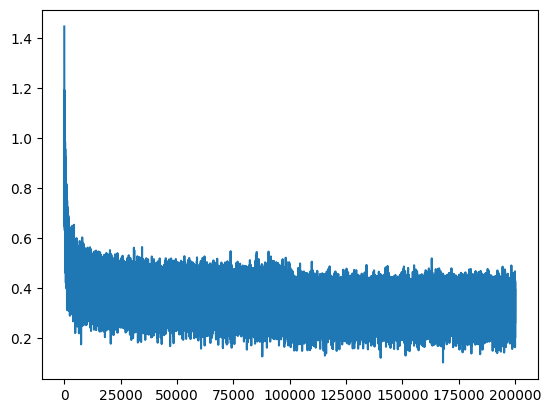

In [31]:
plt.plot(lossi)

In [33]:

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embed)
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (N, block_size * m_embed)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.121133804321289
val 2.164154291152954


for i in range(20):
    out = []
    ctx = [0] * block_size
    while True:
        emb = C[torch.tensor([ctx])]
        # emb.shape[0] is actually 1
        z = emb.view(emb.shape[0], -1) @ W1 + b1
        h = torch.tanh(z)
        logits = h @ W2 + b2
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.softmax.html
        probs = F.softmax(logits, dim = 1)
        idx = torch.multinomial(probs, num_samples = 1, replacement = True, generator = g).item()
        ctx = ctx[1:] + [idx]
        c = itos[idx]
        out.append(c)
        if idx == 0:
            break
    print(''.join(out))

<hr/>

## Initialization

### Logits
As we can see the initialization loss is `27.8817` which is unreasonable large. I expect much lower loss.
The next possible token should be 1 of the 26 chars. And initial probability distribution should be uniform distribution among 27 chars. The following code illustrate that to limit the value of initial loss, we should try to make logitis to be close to 0.

Although we don't necessary need all values in logits to be 0 (as long as they are same number). But by symmetry, we want them close to 0. Because 0 is the most fair / neutral / unbiased center point.

Note
I don't really understand the 0 value thing

In [19]:
## The suppose initial loss should be following in 27 dimension-output
theory_loss = -torch.tensor(1/27.0).log().item()
print('loss we expect (27D):', theory_loss)


## We supppose the label is 2 with 4 dimension-output
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits, dim = 0)
illustration_loss = -probs[2].log()
print('loss we expect (4D): ', illustration_loss.item())


## The logitis corresponds to label
logits = torch.tensor([0.0, 0.0, 5.0, 0.0])
probs = torch.softmax(logits, dim = 0)
illustration_loss = -probs[2].log()
print('Corresponding loss:', illustration_loss.item())


## The logitis do not correspond to label
logits = torch.tensor([-3.0, 5.0, 0.0, 2.0])
probs = torch.softmax(logits, dim = 0)
illustration_loss = -probs[2].log()
print('Uncorresponding loss:', illustration_loss.item())


## The logitis do not correspond to label
# Noramlly distributed small numbers (close to 0)
logits = torch.randn(4)
probs = torch.softmax(logits, dim = 0)
illustration_loss = -probs[2].log()
# Since logits are close to 0, the even the logits to not corresponding to lable, the loss is still relativly good
print('Nornaml distributed small numbers loss:', illustration_loss.item())


## The logitis do not correspond to label
# Noramlly distributed large numbers
logits = torch.randn(4) * 50
probs = torch.softmax(logits, dim = 0)
illustration_loss = -probs[2].log()
# Loss is horrible
print('Nornaml distributed largre numbers loss:', illustration_loss.item())

# Although we don't necessary need all values in logits to be 0 (as long as they are same number). But by symmetry, we want them close to 0
# 0 is the most fair / neutral / unbiased center point

loss we expect (27D): 3.295836925506592
loss we expect (4D):  1.3862943649291992
Corresponding loss: 0.020012274384498596
Uncorresponding loss: 5.055302619934082
Nornaml distributed small numbers loss: 2.02242112159729
Nornaml distributed largre numbers loss: 75.12973022460938


So we want to transform all value of logits to be 0, we initialize the w2 and b2 by timing them with 0 and 0.01 repectively. We don't times W2 with 0.01 (TBD)

In [75]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0 

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


In [77]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.1857
  10000/ 200000: 1.8734
  20000/ 200000: 1.9344
  30000/ 200000: 2.0513
  40000/ 200000: 2.2273
  50000/ 200000: 2.1511
  60000/ 200000: 2.1176
  70000/ 200000: 2.8093
  80000/ 200000: 2.6944
  90000/ 200000: 2.2984
 100000/ 200000: 2.2699
 110000/ 200000: 1.8550
 120000/ 200000: 2.1641
 130000/ 200000: 1.9782
 140000/ 200000: 1.8181
 150000/ 200000: 2.4424
 160000/ 200000: 2.2711
 170000/ 200000: 1.8003
 180000/ 200000: 1.9056
 190000/ 200000: 2.1542


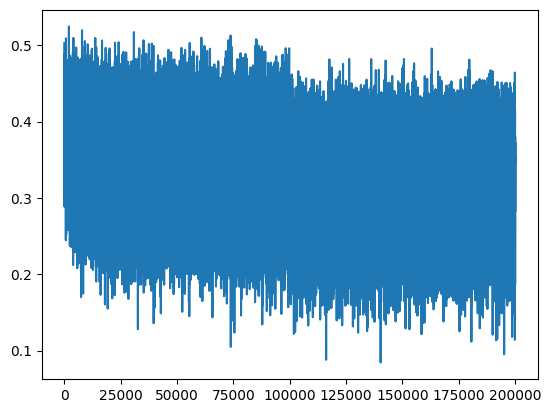

In [78]:
plt.plot(lossi)

In [79]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embed)
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (N, block_size * m_embed)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.070836305618286
val 2.1331448554992676


#### Benefits
We can see that the loss plots is not a husky stick anymore. Since the initial loss is relatively low, we don't waste too much iterations on squashing weights, instead working on optimizing the weights directly. So the final train and validation loss are lower.

### Saturation tanh

In [80]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0 

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


In [81]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  break

      0/ 200000: 3.3221


(array([2069.,  144.,  106.,   82.,   59.,   56.,   43.,   31.,   43.,
          26.,   16.,   38.,   16.,   32.,   24.,   14.,   28.,   27.,
          26.,   19.,   24.,   26.,   30.,   14.,   19.,   19.,   22.,
          26.,   18.,   12.,   10.,   33.,   27.,   32.,   17.,   24.,
          30.,   22.,   26.,   29.,   26.,   40.,   29.,   41.,   49.,
          64.,   62.,  100.,  188., 2442.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

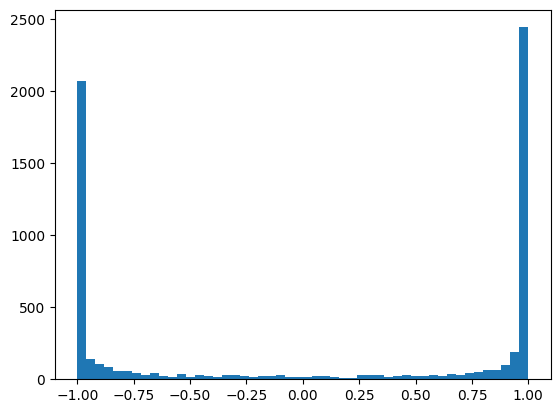

In [82]:
plt.hist(h.view(-1).tolist(), 50)

(array([  2.,   2.,   1.,   4.,   2.,   4.,   6.,  15.,   5.,  25.,  32.,
         49.,  56.,  59.,  92., 119., 134., 197., 195., 221., 257., 275.,
        297., 341., 353., 375., 369., 349., 358., 362., 271., 312., 229.,
        206., 190., 167.,  87., 111.,  72.,  55.,  41.,  22.,  23.,  18.,
         17.,   8.,   5.,   7.,   2.,   1.]),
 array([-19.05793762, -18.31571915, -17.57350067, -16.8312822 ,
        -16.08906372, -15.34684525, -14.60462677, -13.86240829,
        -13.12018982, -12.37797134, -11.63575287, -10.89353439,
        -10.15131592,  -9.40909744,  -8.66687897,  -7.92466049,
         -7.18244202,  -6.44022354,  -5.69800507,  -4.95578659,
         -4.21356812,  -3.47134964,  -2.72913116,  -1.98691269,
         -1.24469421,  -0.50247574,   0.23974274,   0.98196121,
          1.72417969,   2.46639816,   3.20861664,   3.95083511,
          4.69305359,   5.43527206,   6.17749054,   6.91970901,
          7.66192749,   8.40414597,   9.14636444,   9.88858292,
         10.630801

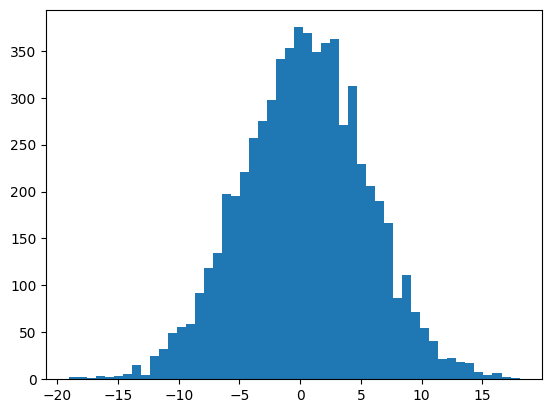

In [83]:
plt.hist(hpreact.view(-1).tolist(), 50)

We can see that `hpreact` spans large magnitudes, so after applying `tanh`, many values become close to `+1` or `-1`.

In the code sample we can see, the `tanh` backward rule:

$$
\frac{d}{dx}\tanh(x) = 1 - \tanh(x)^2
$$

So in backprop we have:

```py
self.grad += (1 - t**2) * out.grad
```
- When $t \approx \pm1, (1 - t^2) \approx 0$, so gradients become very small → learning slows down (saturation / vanishing gradients).
    - The output becomes insensitive to small changes in input:

- When $t \approx 0, (1 - t^2) \approx 1$, so the gradient passes through almost unchanged
    - output is very sensitive to small changes in input.


```python
 def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, _children = (self,), _op="tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out
```

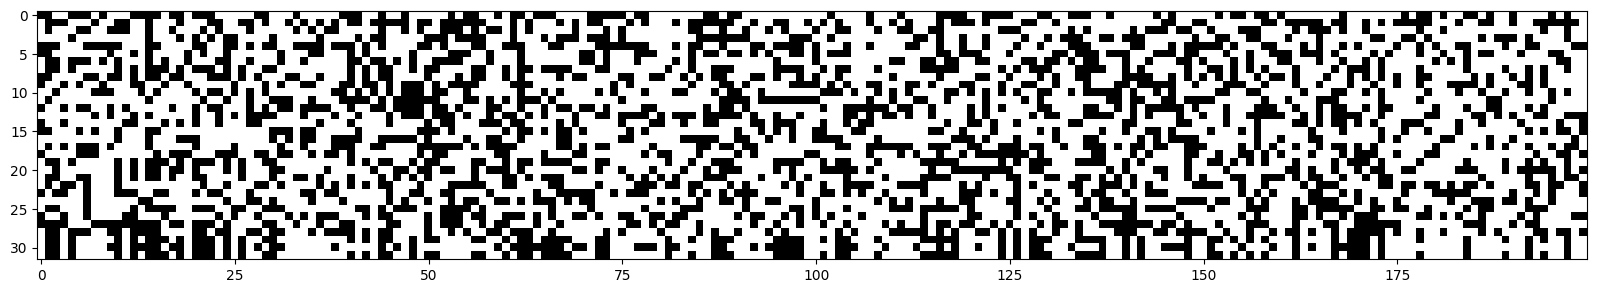

In [92]:
plt.figure(figsize=(20, 10))
# white: true 
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

We can see 32 examples with 200 neurons. The white square means the tanh value is close to 1 or -1. If the whole column is white then it is dead neuron, the weight and bias will be at inactivate region and the neuron won't learn anything thorugh 32 examples.


Sigmoid and Relu may have same problems. The Leaky ReLU, ELU won't suffer from this issue too much.

<img src="./assets/activation-functions.png" style="max-width: 600px; margin: 0 auto">

Altough there is no single column in `imshow` is totally white, but we still want to minize the number of whites in each column. The goal is that to decrease the range of distribution of h_pre_activation value.
- W1 * 0.2
- b1 * 0.01

In [101]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0 

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


In [102]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  break

      0/ 200000: 3.3135


(array([  1.,   2.,   0.,   1.,   5.,   3.,  11.,   6.,  13.,  10.,  25.,
         40.,  40.,  77.,  63., 101., 127., 171., 184., 220., 227., 267.,
        312., 301., 356., 367., 376., 360., 370., 331., 298., 278., 292.,
        242., 191., 167., 137., 104.,  85.,  77.,  41.,  30.,  28.,  20.,
         11.,   7.,  11.,   5.,   2.,   7.]),
 array([-3.76367116, -3.6200974 , -3.47652364, -3.33294988, -3.18937612,
        -3.04580235, -2.90222859, -2.75865483, -2.61508107, -2.47150731,
        -2.32793355, -2.18435979, -2.04078603, -1.89721227, -1.75363851,
        -1.61006474, -1.46649098, -1.32291722, -1.17934346, -1.0357697 ,
        -0.89219594, -0.74862218, -0.60504842, -0.46147466, -0.3179009 ,
        -0.17432714, -0.03075337,  0.11282039,  0.25639415,  0.39996791,
         0.54354167,  0.68711543,  0.83068919,  0.97426295,  1.11783671,
         1.26141047,  1.40498424,  1.548558  ,  1.69213176,  1.83570552,
         1.97927928,  2.12285304,  2.2664268 ,  2.41000056,  2.55357432,
 

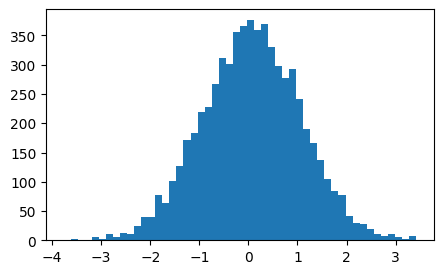

In [103]:
plt.figure(figsize=(5, 3))
plt.hist(hpreact.view(-1).tolist(), 50)

(array([143., 172., 172., 161., 142., 151., 133., 116., 116., 143.,  95.,
        104., 126., 111., 119.,  91.,  86.,  90., 115., 100., 112., 122.,
        111.,  77., 103., 119., 100., 106.,  91.,  90., 117., 114., 116.,
        115., 107., 131., 111., 109., 114., 118., 142., 127., 162., 169.,
        152., 197., 184., 192., 208., 198.]),
 array([-9.98924255e-01, -9.58988956e-01, -9.19053657e-01, -8.79118358e-01,
        -8.39183059e-01, -7.99247760e-01, -7.59312460e-01, -7.19377161e-01,
        -6.79441862e-01, -6.39506563e-01, -5.99571264e-01, -5.59635965e-01,
        -5.19700665e-01, -4.79765366e-01, -4.39830067e-01, -3.99894768e-01,
        -3.59959469e-01, -3.20024170e-01, -2.80088871e-01, -2.40153571e-01,
        -2.00218272e-01, -1.60282973e-01, -1.20347674e-01, -8.04123747e-02,
        -4.04770756e-02, -5.41776419e-04,  3.93935227e-02,  7.93288219e-02,
         1.19264121e-01,  1.59199420e-01,  1.99134719e-01,  2.39070019e-01,
         2.79005318e-01,  3.18940617e-01,  3.58875

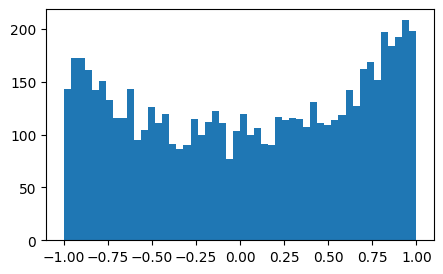

In [104]:
plt.figure(figsize=(5, 3))
plt.hist(h.view(-1).tolist(), 50)

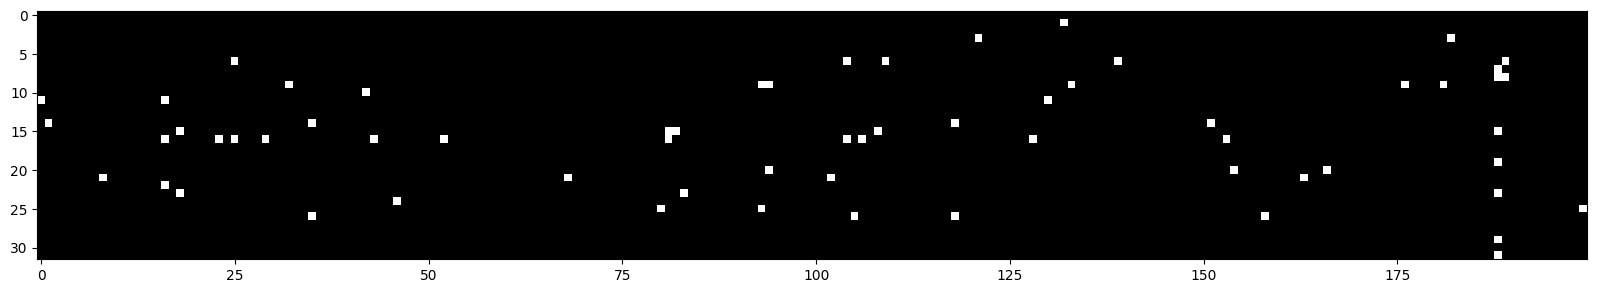

In [105]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [106]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.2466
  10000/ 200000: 1.9222
  20000/ 200000: 1.8991
  30000/ 200000: 1.9745
  40000/ 200000: 2.0871
  50000/ 200000: 1.9749
  60000/ 200000: 2.0796
  70000/ 200000: 2.3772
  80000/ 200000: 2.5110
  90000/ 200000: 2.1863
 100000/ 200000: 2.2270
 110000/ 200000: 1.8214
 120000/ 200000: 2.2077
 130000/ 200000: 1.9776
 140000/ 200000: 1.7861
 150000/ 200000: 2.3862
 160000/ 200000: 2.0314
 170000/ 200000: 1.6659
 180000/ 200000: 1.8944
 190000/ 200000: 2.0666


In [107]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embed)
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (N, block_size * m_embed)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0366742610931396
val 2.1033570766448975


**Raw Initialization**
- train 2.121133804321289
- val 2.164154291152954

**Reducing Logits**
- train 2.070836305618286
- val 2.1331448554992676

**tanh saturation prevention (by times W1 with 0.2)**
- train 2.0366742610931396
- val 2.1033570766448975

We can see that each enhanecement reduces the final loss, because we don't spend iterations on squashing down weights just go strat to the optimization process. In our neural network, if we don't do such enhancement, since the NN is shallow it can still learn just has worse result. But if the NN is large and deep then it may may not learn at all.

### How to find the Proper Scales


#### Refs
- https://arxiv.org/abs/1502.01852
- https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.kaiming_normal_
- https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.calculate_gain

#### Important Innovation after This Paper
Before the following practices, weight and bias initialization is delicate and crucial. The whole training result is strongly influenced by it. But after innovation of the followign practice, it is relatively not crucial anymore, so Karpathy tends to just times weight by $\frac{1}{\sqrt{\text{fan\_in}}}$ 

$\text{fan\_in}$: number of inputs of the layer 


- Batch normalization, layer normalzin, group normalization
- optimizer
    - ARS prop, adams
 

#### Note
But in the following demo case, it is a simple linear case so it is still follow the kaiming_normal by using gain `1`. The tanh uses gain `5/3` because, tanh squashes down the original distribution to range [-1, 1] so it needs to expand distribution a bit to make the std of result stays close to 1 (original normal distribution has std 1).


tensor(0.0190) tensor(0.9889)
tensor(-0.0028) tensor(1.6407)


(array([2.0000e+00, 0.0000e+00, 0.0000e+00, 7.0000e+00, 8.0000e+00,
        1.2000e+01, 2.2000e+01, 4.4000e+01, 7.4000e+01, 1.1400e+02,
        1.6100e+02, 2.5200e+02, 3.9100e+02, 6.2800e+02, 9.9000e+02,
        1.5160e+03, 2.0780e+03, 3.0770e+03, 4.4150e+03, 6.0730e+03,
        8.1640e+03, 1.0372e+04, 1.2817e+04, 1.5131e+04, 1.7029e+04,
        1.8163e+04, 1.7898e+04, 1.6856e+04, 1.5028e+04, 1.2461e+04,
        1.0001e+04, 7.7370e+03, 5.6840e+03, 4.0710e+03, 2.8870e+03,
        2.0190e+03, 1.3610e+03, 9.1800e+02, 5.5600e+02, 3.6300e+02,
        2.2900e+02, 1.5300e+02, 8.6000e+01, 6.4000e+01, 3.4000e+01,
        2.2000e+01, 1.5000e+01, 8.0000e+00, 5.0000e+00, 4.0000e+00]),
 array([-8.9930706 , -8.64607508, -8.29907955, -7.95208403, -7.6050885 ,
        -7.25809298, -6.91109745, -6.56410192, -6.2171064 , -5.87011087,
        -5.52311535, -5.17611982, -4.8291243 , -4.48212877, -4.13513325,
        -3.78813772, -3.4411422 , -3.09414667, -2.74715115, -2.40015562,
        -2.0531601 , -1.70

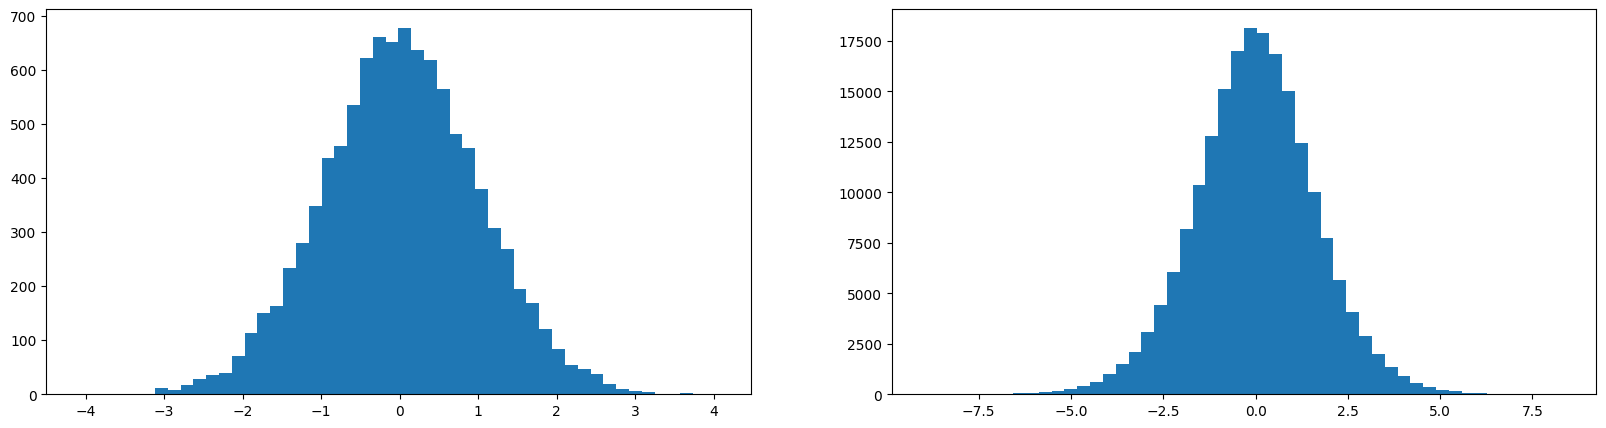

In [133]:
# 1000 inputs, 10 outputs (dimension/neurons)
x = torch.randn(1000, 10)

# 10 inputs, 200 outputs
# raw initialization
# w = torch.randn(10, 200)
# kaiming normalization
w = torch.randn(10, 200) / 10**0.5


y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize = (20, 5))
# In 1 row 2 columns figure, the fig locates at 1st column
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50)

# In 1 row 2 columns figure, the fig locates at 2nd column
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50)


troch.randn return value that are retrieved from noraml distribution with mean 0 and std 1. We can see that wihtout optimization, the standard deviation of y becomes larger. We want the std to remain close to 1.


Now lets implement the [kaiming normal](https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.kaiming_normal_) in our case. So we can remove the magic number 0.2. Actually the magic number should be 0.3.

In [130]:
torch.randn(10000).std()
(torch.randn(10000) *  (5/3) / (n_embd * block_size)**0.5).std()
(5/3) / (n_embd * block_size)**0.5

0.2886751345948129

In [131]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0 

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11697


In [132]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.3173
  10000/ 200000: 2.1861
  20000/ 200000: 2.3421
  30000/ 200000: 2.5209
  40000/ 200000: 1.9577
  50000/ 200000: 2.3483
  60000/ 200000: 2.3813
  70000/ 200000: 2.1712
  80000/ 200000: 2.3335
  90000/ 200000: 2.1574
 100000/ 200000: 1.7870
 110000/ 200000: 2.1641
 120000/ 200000: 1.9471
 130000/ 200000: 2.3512
 140000/ 200000: 2.0598
 150000/ 200000: 2.1645
 160000/ 200000: 1.8034
 170000/ 200000: 1.8006
 180000/ 200000: 2.0117
 190000/ 200000: 1.8283


In [134]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embed)
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (N, block_size * m_embed)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.039020538330078
val 2.1084773540496826


**Raw Initialization**
- train 2.121133804321289
- val 2.164154291152954

**Reducing Logits**
- train 2.070836305618286
- val 2.1331448554992676

**tanh saturation prevention (by times W1 with magic number 0.2)**
- train 2.0366742610931396
- val 2.1033570766448975

**tanh saturation prevention (kaiming norm)**
- train 2.039020538330078
- val 2.1084773540496826

</hr>

<hr/>

## Batch Normalization
- [paper](https://arxiv.org/abs/1502.03167)

### Goal
We want initialization of h_pre_activation to be normal distributed. Becuase if the range is too large, then the `h` will saturated, if the range is too small, then the tanh won't have any influence on them. (inactive / no non-linearity).
So we can just normalize the hidden states h_pre_activation to get gaussian distribution.

### batch norm vs. Kaiming norm
#### Kaiming norm
Kaiming init is simple for small/shallow networks, but for very deep networks
it becomes hard to keep activations and gradients stable using only a Gaussian
weight scale.

- In shallow networks, even if the initialization scale is slightly off,
  activations/gradients usually won’t explode or vanish too badly.
- In deep networks, a tiny mismatch in scale compounds layer-by-layer, which
  can cause activations/gradients to explode or vanish.

So Kaiming init helps, but for deep nets it is often not enough by itself.


## Batch Normalization (BatchNorm)

BatchNorm helps keep the activations at each layer well-behaved by normalizing
them (roughly to mean 0 and variance 1, without shifting and scaling) during training.

This makes training much more stable, especially in deep networks, because the
activation distribution is continuously "corrected" instead of relying only on
a perfect initialization.

### Others
- In convention, we add batch norm layer after each linear layer before non-linear activation layer.



### Formula 
- Compute mean and variance of each input feature:
  $$
  \mu = \frac{1}{m}\sum_i x^{(i)}, \quad \sigma^2 = \frac{1}{m}\sum_i (x^{(i)} - \mu)^2
  $$
- Normalize:
  $$
  x_{\text{norm}} = \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}}
  $$
- Scale and shift
    $$
    \tilde{z}^{(i)} = \gamma \, z_{\text{norm}}^{(i)} + \beta
    $$

- Now $\tilde{z}$ replaces $z$ in the forward pass:
    $$
    a^{[l]} = g(\tilde{z}^{[l]})
    $$

#### $\beta$ and $\gamma$
Ｄuring training, γ and β are **learned** (updated with gradient descent), allowing the network to:
- Choose its own optimal mean and variance for each layer.
- If we always force mean = 0 and variance = 1, the network may lose expressive power.
For example, with a sigmoid activation, values near 0 correspond to the linear (flat) region, making learning inefficient.

| Parameter | Role | Analogy | Effect |
|------------|------|----------|--------|
| **γ (gamma)** | Scale | Like standard deviation | Controls how “spread out” activations are (variance) |
| **β (beta)** | Shift | Like mean | Moves activations up or down (mean) |


#### Epsilon
- The epsilon is a small number to prevent errors caused by $sigma$ being 0.
- In the case, it dosen't matter, so we just omit it.

## Jittering (Noise)
Because BatchNorm normalizes activations using the mean/std of the *current mini-batch*,
the normalized pre-activations (`hpreact`) change slightly from batch to batch.

This introduces noise ("jitter") into the hidden activations `h`, which often acts as an
implicit regularizer and can reduce overfitting (similar in spirit to adding noise during training).

In [8]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0 

# batch norm params
bn_gain = torch.ones((1, n_hidden))
bn_bias = torch.zeros((1, n_hidden))

parameters = [C, W1, W2, b2, bn_gain, bn_bias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [9]:
hpreact.shape # 32 examples (batch_size), 200 neurons
# we need to know the mean and std for each neurons accross 32 examples

NameError: name 'hpreact' is not defined

In [10]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1
  # Batch normalization
  bnmeani = hpreact.mean(0, keepdim=True) # Calculate mean and std over row, keepdim for brodcasting 
  bnstdi = hpreact.std(0, keepdim=True)
  normed_hpreact = bn_gain * (hpreact - bnmeani) / bnstdi + bn_bias
  hpreact = bn_gain * normed_hpreact + bn_bias
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.3147
  10000/ 200000: 2.2119
  20000/ 200000: 2.3768
  30000/ 200000: 2.4750
  40000/ 200000: 1.9512
  50000/ 200000: 2.2498
  60000/ 200000: 2.4208
  70000/ 200000: 2.0134
  80000/ 200000: 2.4327
  90000/ 200000: 2.1986
 100000/ 200000: 1.9451
 110000/ 200000: 2.3135
 120000/ 200000: 2.0137
 130000/ 200000: 2.4886
 140000/ 200000: 2.3626
 150000/ 200000: 2.2529
 160000/ 200000: 1.9295
 170000/ 200000: 1.8342
 180000/ 200000: 1.9036
 190000/ 200000: 1.8493


In [11]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embed)
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (N, block_size * m_embed)
  hpreact = embcat @ W1 + b1
  bnmeani = hpreact.mean(0, keepdim=True) # Calculate mean and std over row, keepdim for brodcasting 
  bnstdi = hpreact.std(0, keepdim=True)
  normed_hpreact = bn_gain * (hpreact - bnmeani) / bnstdi + bn_bias
  hpreact = bn_gain * normed_hpreact + bn_bias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0773255825042725
val 2.1141395568847656


**Raw Initialization**
- train 2.121133804321289
- val 2.164154291152954

**Reducing Logits (Fix oftmax confidently wrong)**
- train 2.070836305618286
- val 2.1331448554992676

**tanh saturation prevention (by times W1 with magic number 0.2)**
- train 2.0366742610931396
- val 2.1033570766448975

**tanh saturation prevention (insteadf of magic number 0.2, we use kaiming init)**
- train 2.039020538330078
- val 2.1084773540496826

**add batch norm layer**
- train 2.0761992931365967
- val 2.1142008304595947


### Loss observation
Since kaiming initialization has done the guassian normalization, the batch norm won't have too much effects on the model. But in general, we still prefer batch norm over kaiming. Because in deep network if the kaiming's normalization is a bit off it will have temendous effect on output, but bathc norm works on layer by layer batch by batch so it can be more precise. In a sesne, it has less chance to cause weight saturation or vanish problem.


### Downsides
Although the noise traits of batch norm offers regularization, People don’t like BatchNorm’s coupled forward pass. Because it makes each sample’s output depend on other samples in the batch, causing batch-size sensitivity, train/test differences, and headaches in inference + distributed training.
So there are multiple altenatives for batch_norm. Layer normalization, instance normalization, group normalization, etc.

### train batch mean and std
- We actually should use mean and std over entire training set to do bathc norma in test and validation inference.
- We can create another stage to calculate training set mean and std or during training process. The sceond one is the prefered method in paper.
- In training process we implement [exponential smoothing](https://en.wikipedia.org/wiki/Exponential_smoothing) to approximate the mean and std over training set
    - [exponential smoothing explanation](https://www.youtube.com/watch?v=k_HN0wOKDd0)

In [164]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0 

# batch norm params
bn_gain = torch.ones((1, n_hidden))
bn_bias = torch.zeros((1, n_hidden))

parameters = [C, W1, W2, b2, bn_gain, bn_bias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [165]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1
  # Batch normalization
  bnmeani = hpreact.mean(0, keepdim=True) # Calculate mean and std over row, keepdim for brodcasting 
  bnstdi = hpreact.std(0, keepdim=True)
  normed_hpreact = bn_gain * (hpreact - bnmeani) / bnstdi + bn_bias
  hpreact = bn_gain * normed_hpreact + bn_bias
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.3147
  10000/ 200000: 2.2061
  20000/ 200000: 2.3796
  30000/ 200000: 2.4679
  40000/ 200000: 1.9536
  50000/ 200000: 2.2439
  60000/ 200000: 2.4363
  70000/ 200000: 2.0243
  80000/ 200000: 2.4347
  90000/ 200000: 2.1670
 100000/ 200000: 1.9236
 110000/ 200000: 2.3590
 120000/ 200000: 1.9828
 130000/ 200000: 2.4785
 140000/ 200000: 2.3280
 150000/ 200000: 2.2584
 160000/ 200000: 1.8881
 170000/ 200000: 1.8195
 180000/ 200000: 1.9156
 190000/ 200000: 1.8547


In [166]:
# calibrate the batch norm at the end of training
# New Stage
with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)
bnmean, bnstd

(tensor([[-2.5372e+00,  6.8219e-01, -1.5373e+00,  7.5955e-01,  1.2343e+00,
           9.2124e-01,  2.0476e+00, -1.1082e+00,  1.5095e-01,  3.2984e+00,
          -1.8234e+00, -2.6993e+00, -4.0587e-01, -3.0601e-01,  3.0414e-01,
           3.0873e-01,  7.9409e-01, -3.0481e+00, -6.7735e-01,  1.5269e+00,
          -1.4732e-01,  2.7655e-01,  4.9110e-01,  6.7595e-01,  7.5879e-01,
          -9.9012e-02,  7.0703e-01,  8.7534e-01,  3.4013e-01,  1.6085e+00,
          -4.8281e-01, -8.9717e-01,  8.2589e-01, -2.4007e-02, -8.6837e-01,
          -1.0310e+00, -1.0341e+00, -9.5370e-02, -7.9116e-03,  2.2339e-01,
           7.3476e-02, -9.5795e-01, -5.6848e-02,  1.9901e-01,  4.0883e-01,
           4.9824e-02,  1.6737e+00, -1.0239e+00,  2.4801e+00,  1.4055e-01,
           6.7081e-01,  4.2918e-01,  2.4849e+00,  1.1183e+00,  9.0457e-01,
          -1.1634e+00,  7.2257e-01,  2.0148e-02,  6.0689e-01, -1.8666e+00,
          -3.9444e-01,  8.2314e-01,  6.2911e-01,  7.2519e-01,  9.4714e-01,
           8.7972e-01, -7

In [167]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embed)
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors (N, block_size * m_embed)
  hpreact = embcat @ W1 + b1
  normed_hpreact = bn_gain * (hpreact - bnmean) / bnstd + bn_bias
  hpreact = bn_gain * normed_hpreact + bn_bias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0762765407562256
val 2.11438250541687


**Raw Initialization**
- train 2.121133804321289
- val 2.164154291152954

**Reducing Logits (Fix oftmax confidently wrong)**
- train 2.070836305618286
- val 2.1331448554992676

**tanh saturation prevention (by times W1 with magic number 0.2)**
- train 2.0366742610931396
- val 2.1033570766448975

**tanh saturation prevention (insteadf of magic number 0.2, we use kaiming init)**
- train 2.039020538330078
- val 2.1084773540496826

**add batch norm layer**
- train 2.0761992931365967
- val 2.1142008304595947

**add batch norm layer (inference with mean and std fomr training set)**
- train 2.0762765407562256
- val 2.11438250541687

Use exponential smoothing to compute mean and std over training set.
The selection of $/alpha$ is crucial. The value suppose be in range [0,1]. 0.001 is chosen because it makes the running mean/std stable by averaging over ~1000 batches, reducing mini-batch noise, and producing good inference-time statistics (especially with long training).

We initialzie the bnmean_running with 0 and bnmean_std with 1 because our assumption on normal distribtuion
$$
X \sim N(0,1^2)
$$

In [169]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0 

# batch noram params
bn_gain = torch.ones((1, n_hidden))
bn_bias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bn_gain, bn_bias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [170]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + b1
  # Batch normalization
  bnmeani = hpreact.mean(0, keepdim=True) # Calculate mean and std over row, keepdim for brodcasting 
  bnstdi = hpreact.std(0, keepdim=True)
  normed_hpreact = bn_gain * (hpreact - bnmeani) / bnstdi + bn_bias
  hpreact = bn_gain * normed_hpreact + bn_bias
  with torch.no_grad():
      bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
      bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.3147
  10000/ 200000: 2.2061
  20000/ 200000: 2.3796
  30000/ 200000: 2.4679
  40000/ 200000: 1.9536
  50000/ 200000: 2.2439
  60000/ 200000: 2.4363
  70000/ 200000: 2.0243
  80000/ 200000: 2.4347
  90000/ 200000: 2.1670
 100000/ 200000: 1.9236
 110000/ 200000: 2.3590
 120000/ 200000: 1.9828
 130000/ 200000: 2.4785
 140000/ 200000: 2.3280
 150000/ 200000: 2.2584
 160000/ 200000: 1.8881
 170000/ 200000: 1.8195
 180000/ 200000: 1.9156
 190000/ 200000: 1.8547


In [171]:
bnstd_running, bnstd_running

(tensor([[2.4532, 2.0598, 1.6143, 1.5858, 2.1848, 2.3110, 2.4717, 2.2947, 2.5295,
          1.9608, 2.3986, 2.1164, 2.2090, 1.5878, 2.0509, 2.6205, 2.0305, 1.9926,
          2.1513, 2.4522, 2.3603, 2.2820, 2.0507, 1.9300, 2.0246, 1.7023, 2.2246,
          2.4269, 2.1745, 2.3424, 1.2005, 2.0050, 2.0446, 1.2592, 2.0197, 1.3808,
          2.8504, 1.9939, 2.1086, 1.5673, 1.9090, 1.7584, 2.4294, 1.5351, 2.0629,
          1.9224, 2.2927, 2.2559, 2.7172, 2.3439, 1.8120, 1.7974, 2.2556, 1.5278,
          2.5877, 2.5331, 1.8112, 2.1039, 1.9061, 1.8185, 1.8831, 2.0853, 1.9300,
          2.2167, 2.0800, 2.3496, 2.2388, 2.4753, 1.4964, 2.3440, 1.2809, 2.1374,
          2.0905, 1.9216, 1.8940, 1.6095, 2.4897, 2.2691, 1.3625, 2.3277, 1.9379,
          1.3577, 1.2976, 2.1008, 1.9524, 2.4235, 2.3741, 2.2005, 2.7918, 2.7677,
          1.9991, 2.0239, 1.4556, 1.7681, 1.9257, 2.2954, 1.8445, 1.7683, 1.8176,
          2.0200, 2.0357, 2.1554, 2.3459, 2.1431, 1.7253, 2.2111, 1.2387, 2.0463,
          1.6279

We can see that bnstd_running and bnstd_running are approximately equal to bnmean, bnstd

Every linear layer before batch_norm actually dosen't need bias, so We don't need `b1`. Beacuse during the processs `hpreact - bnmeani`, we negate the b1.

```python
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 + # b1 (we don't need this anymore)
  # Batch normalization
  bnmeani = hpreact.mean(0, keepdim=True) # Calculate mean and std over row, keepdim for brodcasting 
  bnstdi = hpreact.std(0, keepdim=True)
  normed_hpreact = bn_gain * (hpreact - bnmeani) / bnstdi + bn_bias
  hpreact = bn_gain * normed_hpreact + bn_bias
```

## Similaryity with ([RESNET](https://github.com/pytorch/vision/blob/91b3aa6344fa68240414680466d9957bfa5cf339/torchvision/models/video/resnet.py#L140))
- The layer stack of MLP and RESNET of CNN are similar. It is comprised of 3 main layers
    1. linear layer (weight layer) (convolution layer is just a linear layer performing on a patch)
    2. Batch Norm
    3. Non-linear layer

- Before each batch_noram layer, the bias is not needed in linear layer

```python
self.conv1 = nn.Sequential(
            nn.Conv3d(inplanes, planes, kernel_size=1, bias=False), nn.BatchNorm3d(planes), nn.ReLU(inplace=True)
        )
```

## Pytorch Lesson
### [Linear layer](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)
The variable section indicate how pytorch initialize weight, the $\frac{1}{\text{in\_features (fan\_in)}}$ is derivied from Kaiming normalziation. pytorch uses uniform distribution for the weights not normal distribution to assure that the normal distributed input go through the layer has normal distributed output.

### [BatchNorm1d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)
- num_features: number of neurons
- eps=1e-05: epsilon
- momentum=0.1
    - the $alpha$ for exponential smoothing
    - If we have large batch_size, then 0.1 is relative good, since the result weights won't jump around and hinder loss convergence. But in our case, the batch_size is relatively small (32), so we stick with 0.001
- affine=True
    - True: The model should have and learn the bngain and bnbias.
    - It is not common to set it to false
- track_running_stats=True
    - Should run this or not
      ```python
          with torch.no_grad():
              bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
              bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
      ```
     - `False`
         - Compute bnmean and bnstd in another stage
           ```python
            # calibrate the batch norm at the end of training
            # New Stage
            with torch.no_grad():
              # pass the training set through
              emb = C[Xtr]
              embcat = emb.view(emb.shape[0], -1)
              hpreact = embcat @ W1 # + b1
              # measure the mean/std over the entire training set
              bnmean = hpreact.mean(0, keepdim=True)
              bnstd = hpreact.std(0, keepdim=True)
            bnmean, bnstd
           ```
- device=None
    - cpu or gpu 
- dtype=None
    - single, double precieions, etc 

## Half-way Summary
- Good summary
- https://youtu.be/P6sfmUTpUmc?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&t=4518
- Key note
    - Bathch norm causes a lot of bugs, use layer norm or group norm instead.  